In [1]:
pip install MLB-StatsAPI

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install --upgrade MLB-StatsAPI

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import statsapi

In [2]:
sched = statsapi.schedule(start_date='07/01/2018',end_date='07/31/2018',team=143,opponent=121)

In [3]:
import logging
logger = logging.getLogger('statsapi')
logger.setLevel(logging.DEBUG)
rootLogger = logging.getLogger()
rootLogger.setLevel(logging.DEBUG)
ch = logging.StreamHandler()
formatter = logging.Formatter("%(asctime)s - %(levelname)8s - %(name)s(%(thread)s) - %(message)s")
ch.setFormatter(formatter)
rootLogger.addHandler(ch)

In [4]:
statsapi.schedule(team=133,start_date='05/1/2026',end_date='09/01/2026')

2026-09-08 12:51:32,919 -    DEBUG - statsapi(61536) - URL: https://statsapi.mlb.com/api/{ver}/schedule
2026-09-08 12:51:32,920 -    DEBUG - statsapi(61536) - Found query param: startDate
2026-09-08 12:51:32,920 -    DEBUG - statsapi(61536) - Found query param: endDate
2026-09-08 12:51:32,920 -    DEBUG - statsapi(61536) - Found query param: teamId
2026-09-08 12:51:32,921 -    DEBUG - statsapi(61536) - Found query param: sportId
2026-09-08 12:51:32,921 -    DEBUG - statsapi(61536) - Found query param: hydrate
2026-09-08 12:51:32,921 -    DEBUG - statsapi(61536) - path_params: {}
2026-09-08 12:51:32,922 -    DEBUG - statsapi(61536) - query_params: {'startDate': '05/1/2026', 'endDate': '09/01/2026', 'teamId': '133', 'sportId': '1', 'hydrate': 'decisions,probablePitcher(note),linescore,broadcasts,game(content(media(epg))),seriesStatus'}
2026-09-08 12:51:32,922 -    DEBUG - statsapi(61536) - Replacing {ver} with default: v1.
2026-09-08 12:51:32,922 -    DEBUG - statsapi(61536) - URL: https

[{'game_id': 825012,
  'game_datetime': '2026-05-02T01:40:00Z',
  'game_date': '2026-05-01',
  'game_type': 'R',
  'status': 'Final',
  'away_name': 'Cleveland Guardians',
  'home_name': 'Athletics',
  'away_id': 114,
  'home_id': 133,
  'doubleheader': 'N',
  'game_num': 1,
  'home_probable_pitcher': 'J.T. Ginn',
  'away_probable_pitcher': 'Joey Cantillo',
  'home_pitcher_note': '',
  'away_pitcher_note': '',
  'away_score': 8,
  'home_score': 5,
  'current_inning': 9,
  'inning_state': 'Bottom',
  'venue_id': 2529,
  'venue_name': 'Sutter Health Park',
  'national_broadcasts': [],
  'series_status': 'CLE leads 1-0',
  'winning_team': 'Cleveland Guardians',
  'losing_team': 'Athletics',
  'winning_pitcher': 'Erik Sabrowski',
  'losing_pitcher': 'J.T. Ginn',
  'save_pitcher': 'Cade Smith',
  'summary': '2026-05-01 - Cleveland Guardians (8) @ Athletics (5) (Final)'},
 {'game_id': 825014,
  'game_datetime': '2026-05-02T20:05:00Z',
  'game_date': '2026-05-02',
  'game_type': 'R',
  'statu

In [9]:
print('The A\'s won %s games in 2020.' % sum(1 for x in statsapi.schedule(team=133,start_date='03/25/2026',end_date='09/08/2026') if x.get('winning_team','')=='Athletics'))

2026-09-08 12:53:29,800 -    DEBUG - statsapi(61536) - URL: https://statsapi.mlb.com/api/{ver}/schedule
2026-09-08 12:53:29,800 -    DEBUG - statsapi(61536) - Found query param: startDate
2026-09-08 12:53:29,801 -    DEBUG - statsapi(61536) - Found query param: endDate
2026-09-08 12:53:29,802 -    DEBUG - statsapi(61536) - Found query param: teamId
2026-09-08 12:53:29,802 -    DEBUG - statsapi(61536) - Found query param: sportId
2026-09-08 12:53:29,802 -    DEBUG - statsapi(61536) - Found query param: hydrate
2026-09-08 12:53:29,803 -    DEBUG - statsapi(61536) - path_params: {}
2026-09-08 12:53:29,803 -    DEBUG - statsapi(61536) - query_params: {'startDate': '03/25/2026', 'endDate': '09/08/2026', 'teamId': '133', 'sportId': '1', 'hydrate': 'decisions,probablePitcher(note),linescore,broadcasts,game(content(media(epg))),seriesStatus'}
2026-09-08 12:53:29,803 -    DEBUG - statsapi(61536) - Replacing {ver} with default: v1.
2026-09-08 12:53:29,805 -    DEBUG - statsapi(61536) - URL: http

The A's won 58 games in 2020.


In [10]:
pip install requests pandas openpyxl


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Below is the code to create a excel file from the api
 
 ** Word of note claude did help me write this gigantic piece of code, just want to be completley transparent. 


In [92]:
"""
MLB World Series Bunt vs. No-Bunt WPA Analysis
======================================================

Pulls play-by-play data for every World Series game across a configurable
range of seasons and creates a complete plate-appearance dataset.

The workbook contains four sheets:

1. AtBats
   Every MLB play/at-bat in the selected games, including:
   - base/out state before and after
   - bunt vs. non-bunt
   - event and description
   - runs scored on the play
   - home_team_wpa: win probability added for the HOME team on that
     play (taken directly from the API's homeTeamWinProbabilityAdded,
     no sign-flipping for who was batting), when available
   - inning and score differential

2. Bunt_vs_NoBunt
   Summary comparison of bunt vs. non-bunt outcomes for each base/out state,
   based on runs on the play and average WPA.

3. Comparison
   Side-by-side bunt vs. no-bunt averages (runs and WPA) per base/out state.

4. Bunt_Outcomes
   Summary of the different bunt outcomes, including average WPA.

IMPORTANT:
- GAME_TYPE = 'W' means World Series in the MLB Stats API.
- "is_bunt" is identified from MLB's event/description text containing "bunt".
- home_team_wpa comes from the separate `game_winProbability` endpoint,
  keyed by atBatIndex, using homeTeamWinProbabilityAdded directly with
  no sign-flipping or batting-team inference. Positive = play helped
  the home team's win probability; negative = play helped the away
  team. Coverage of this endpoint is generally solid for modern
  seasons but can be missing or sparse for older World Series games -
  those plays will show a blank/NaN home_team_wpa rather than a
  guessed one.
- The win-probability endpoint returns percentages (0-100); this script
  divides by 100 so home_team_wpa is on the conventional +/-0.XXX scale.
- NOTE: if home_team_wpa values don't line up with what you'd expect for
  a given play, first check whether the WP endpoint's atBatIndex values
  actually align 1:1 with the play-by-play's atBatIndex for that game -
  a mismatch there (e.g. per-pitch entries vs. per-at-bat) would shift
  every home_team_wpa onto the wrong row.
- This is an observational comparison, not a causal estimate. Bunting is
  chosen strategically, so differences can reflect who bunted and when.
"""

import json
import os
import time

import pandas as pd
import statsapi


# ----------------------------------------------------------------------
# CONFIG
# ----------------------------------------------------------------------

START_YEAR = 2005
END_YEAR = 2025          # inclusive
GAME_TYPE = 'F,D,L,W'           # World Series only
CACHE_DIR = 'mlb_cache'
REQUEST_DELAY = 0.4      # seconds between API calls

OUTPUT_PATH = 'mlb_bunts.xlsx'


os.makedirs(CACHE_DIR, exist_ok=True)


# ----------------------------------------------------------------------
# STEP 1: Get every World Series gamePk in the date range
# ----------------------------------------------------------------------

def get_world_series_game_pks(start_year, end_year):
    """
    Get every World Series gamePk from start_year through end_year.

    statsapi.schedule() does not expose the gameTypes filter we need here,
    so we use the low-level statsapi.get() call against the schedule endpoint.
    """

    game_pks = []

    for year in range(start_year, end_year + 1):

        try:
            response = statsapi.get(
                'schedule',
                {
                    'sportId': 1,
                    'season': year,
                    'gameTypes': GAME_TYPE
                }
            )

        except Exception as exc:
            print(
                f"  [WARN] Could not fetch schedule for "
                f"{year}: {exc}"
            )
            continue

        year_games = []

        for date_block in response.get('dates', []):

            for game in date_block.get('games', []):

                year_games.append(
                    {
                        'season': year,
                        'game_pk': game['gamePk']
                    }
                )

        game_pks.extend(year_games)

        print(
            f"{year}: found {len(year_games)} "
            f"World Series game(s)"
        )

        time.sleep(REQUEST_DELAY)

    return game_pks


# ----------------------------------------------------------------------
# STEP 2: Fetch and cache play-by-play for one game
# ----------------------------------------------------------------------

def get_play_by_play(game_pk):
    """
    Download play-by-play JSON for a game, unless it is already cached.
    """

    cache_path = os.path.join(
        CACHE_DIR,
        f'{game_pk}.json'
    )

    if os.path.exists(cache_path):

        with open(cache_path, 'r') as file:
            return json.load(file)

    print(f"    Downloading play-by-play for {game_pk}...")

    data = statsapi.get(
        'game_playByPlay',
        {'gamePk': game_pk}
    )

    with open(cache_path, 'w') as file:
        json.dump(data, file)

    time.sleep(REQUEST_DELAY)

    return data


# ----------------------------------------------------------------------
# STEP 2b: Fetch and cache win probability for one game
# ----------------------------------------------------------------------

def get_win_probability(game_pk):
    """
    Download win-probability-by-play data for a game, unless already cached.

    Returns a list of records (one per play/atBatIndex) from MLB's
    `game_winProbability` endpoint, or an empty list if the endpoint has
    no data for this game (common for older games).
    """

    cache_path = os.path.join(
        CACHE_DIR,
        f'{game_pk}_wp.json'
    )

    if os.path.exists(cache_path):

        with open(cache_path, 'r') as file:
            return json.load(file)

    print(f"    Downloading win probability for {game_pk}...")

    try:
        data = statsapi.get(
            'game_winProbability',
            {'gamePk': game_pk}
        )

    except Exception as exc:
        print(
            f"    [WARN] No win probability data for "
            f"{game_pk}: {exc}"
        )
        data = []

    # This endpoint sometimes wraps the list in a dict depending on
    # statsapi/MLB API version - normalize to a plain list either way.
    if isinstance(data, dict):
        data = data.get('winProbability', []) or []

    with open(cache_path, 'w') as file:
        json.dump(data, file)

    time.sleep(REQUEST_DELAY)

    return data


def build_wpa_lookup(win_probability_rows):
    """
    Build a dict of {atBatIndex: home_team_wpa} from the raw
    win-probability records for a game.

    This takes 'homeTeamWinProbabilityAdded' directly from the API,
    with no sign-flipping or batting-team inference, and normalizes
    it from a 0-100 percentage scale to a +/-0.XXX fraction.

    A positive value means the play increased the HOME team's win
    probability, regardless of who was batting. A negative value
    means it decreased the home team's win probability (i.e. helped
    the away team).
    """

    lookup = {}

    for record in win_probability_rows:

        at_bat_index = record.get('atBatIndex')

        if at_bat_index is None:
            continue

        home_wpa = record.get('homeTeamWinProbabilityAdded')

        if home_wpa is None:
            continue

        lookup[at_bat_index] = home_wpa / 100.0

    return lookup


# ----------------------------------------------------------------------
# STEP 3: Base-state helper
# ----------------------------------------------------------------------

def base_state(matchup):
    """
    Return the base configuration represented by the matchup's
    postOnFirst/postOnSecond/postOnThird fields.

    Examples:

        ''       = bases empty
        '1'      = runner on first
        '2'      = runner on second
        '3'      = runner on third
        '1_2'    = first and second
        '1_3'    = first and third
        '2_3'    = second and third
        '1_2_3'  = bases loaded
    """

    bases = []

    if 'postOnFirst' in matchup:
        bases.append('1')

    if 'postOnSecond' in matchup:
        bases.append('2')

    if 'postOnThird' in matchup:
        bases.append('3')

    return '_'.join(bases)


# ----------------------------------------------------------------------
# STEP 4: Bunt helpers
# ----------------------------------------------------------------------

def is_bunt_play(play):
    """
    Identify a bunt from MLB's event or description text.

    This deliberately uses the same basic detection logic as the original
    script so that the definition of a bunt remains consistent.
    """

    result = play.get('result', {})

    event = result.get('event', '') or ''
    description = result.get('description', '') or ''

    return (
        'bunt' in event.lower()
        or 'bunt' in description.lower()
    )


def classify_bunt(event, description, outs_before, outs_after):
    """
    Best-effort classification of bunt outcomes.

    MLB event labels can vary somewhat by season/scorer, so the raw event
    and description are also retained in the AtBats sheet.
    """

    event = event or ''
    description = description or ''

    e = event.lower()
    d = description.lower()

    outs_recorded = outs_after - outs_before

    if 'sac bunt' in e:
        if outs_recorded <= 1:
            return 'Successful Sac'
        return 'Sac Bunt Double Play'

    if 'bunt' in e and 'double play' in e:
        return 'Double Play'

    if 'bunt' in e and (
        'pop out' in e
        or 'popout' in e
    ):
        return 'Popout'

    if 'bunt' in e and 'single' in e:
        return 'Reached Base (Bunt Hit)'

    if 'bunt' in e and 'error' in d:
        return 'Reached Base (Error)'

    if 'fielders choice' in e and 'bunt' in d:
        return 'Runner Thrown Out (Fielders Choice)'

    if 'bunt' in e and 'groundout' in e:
        return 'Runner/Batter Thrown Out'

    return f'Other/Review: {event}'


# ----------------------------------------------------------------------
# STEP 5: Process one game
# ----------------------------------------------------------------------

def process_game(game_pk, season):
    """
    Process a game into a list of at-bat rows (one per play), including
    both bunts and non-bunts, with WPA attached where available.
    """

    data = get_play_by_play(game_pk)

    win_probability_rows = get_win_probability(game_pk)
    wpa_lookup = build_wpa_lookup(win_probability_rows)

    all_plays = sorted(
        data.get('allPlays', []),
        key=lambda p: p['about']['atBatIndex']
    )

    # Group plays by half-inning so we can determine the eventual
    # runs scored by that offensive team after each play.
    def half_inning_key(play):
        about = play['about']

        return (
            about['inning'],
            about['isTopInning']
        )

    plays_by_half = {}

    for play in all_plays:

        key = half_inning_key(play)

        plays_by_half.setdefault(
            key,
            []
        ).append(play)

    at_bat_rows = []

    # Current score.
    away_score = 0
    home_score = 0

    # State immediately before the current play.
    prior_bases = ''
    prior_outs = 0

    current_half_key = None

    for play in all_plays:

        about = play['about']
        result = play['result']
        matchup = play.get('matchup', {})
        count = play.get('count', {})

        key = half_inning_key(play)

        # Reset base/out state at the beginning of every half-inning.
        if key != current_half_key:

            prior_bases = ''
            prior_outs = 0
            current_half_key = key

        # --------------------------------------------------------------
        # STATE BEFORE THE PLAY
        # --------------------------------------------------------------

        away_before = away_score
        home_before = home_score

        base_before = prior_bases
        outs_before = prior_outs

        # --------------------------------------------------------------
        # STATE AFTER THE PLAY
        # --------------------------------------------------------------

        base_after = base_state(matchup)

        outs_after = count.get(
            'outs',
            outs_before
        )

        away_after = result.get(
            'awayScore',
            away_before
        )

        home_after = result.get(
            'homeScore',
            home_before
        )

        # --------------------------------------------------------------
        # IDENTIFY OFFENSIVE TEAM
        # --------------------------------------------------------------

        is_top = about['isTopInning']

        team_before = (
            away_before
            if is_top
            else home_before
        )

        team_after = (
            away_after
            if is_top
            else home_after
        )

        # --------------------------------------------------------------
        # DETERMINE END-OF-HALF-INNING SCORE
        # --------------------------------------------------------------

        final_play_of_half = plays_by_half[key][-1]

        final_team_score = final_play_of_half[
            'result'
        ].get(
            'awayScore'
            if is_top
            else 'homeScore',
            team_after
        )

        runs_rest_of_inning = (
            final_team_score - team_before
        )

        # --------------------------------------------------------------
        # BUNT STATUS
        # --------------------------------------------------------------

        bunt = is_bunt_play(play)

        event = result.get(
            'event',
            ''
        )

        description = result.get(
            'description',
            ''
        )

        bunt_outcome = ''

        if bunt:

            bunt_outcome = classify_bunt(
                event,
                description,
                outs_before,
                outs_after
            )

        # --------------------------------------------------------------
        # GAME CONTEXT
        # --------------------------------------------------------------

        score_diff_before = (
            away_before - home_before
            if is_top
            else home_before - away_before
        )

        # --------------------------------------------------------------
        # WPA (home team perspective, straight from the API)
        # --------------------------------------------------------------

        at_bat_index = about['atBatIndex']
        home_team_wpa = wpa_lookup.get(at_bat_index)

        # --------------------------------------------------------------
        # SAVE EVERY PLAY / AT-BAT
        # --------------------------------------------------------------

        at_bat_rows.append(
            {
                'season': season,
                'game_pk': game_pk,

                'inning': about['inning'],
                'is_top_inning': is_top,

                'at_bat_index':
                    at_bat_index,

                'base_state_before':
                    base_before,

                'outs_before':
                    outs_before,

                'base_state_after':
                    base_after,

                'outs_after':
                    outs_after,

                'is_bunt':
                    bunt,

                'bunt_outcome':
                    bunt_outcome,

                'raw_event':
                    event,

                'description':
                    description,

                'runs_on_play':
                    team_after - team_before,

                'runs_after_play':
                    final_team_score - team_after,

                'runs_rest_of_inning':
                    runs_rest_of_inning,

                'score_diff_before':
                    score_diff_before,

                'home_team_wpa':
                    home_team_wpa
            }
        )

        # --------------------------------------------------------------
        # UPDATE STATE
        # --------------------------------------------------------------

        away_score = away_after
        home_score = home_after

        prior_bases = base_after
        prior_outs = outs_after

    return at_bat_rows


# ----------------------------------------------------------------------
# STEP 6: Bunt vs. no-bunt summary
# ----------------------------------------------------------------------

def build_bunt_vs_no_bunt_summary(at_bat_df):
    """
    Compare bunts and non-bunts within each starting base/out state.

    This gives the most direct observational comparison for the question:

        "In the same base/out situation, how did bunting perform
         relative to not bunting, in terms of win probability?"
    """

    summary = (
        at_bat_df
        .groupby(
            [
                'base_state_before',
                'outs_before',
                'is_bunt'
            ],
            dropna=False
        )
        .agg(
            plate_appearances=(
                'runs_on_play',
                'size'
            ),

            avg_runs_on_play=(
                'runs_on_play',
                'mean'
            ),

            total_runs_on_play=(
                'runs_on_play',
                'sum'
            ),

            avg_wpa=(
                'home_team_wpa',
                'mean'
            ),

            median_wpa=(
                'home_team_wpa',
                'median'
            ),

            wpa_sample_size=(
                'home_team_wpa',
                'count'
            )
        )
        .reset_index()
    )

    # Make the labels easier to read in Excel.
    summary['strategy'] = summary[
        'is_bunt'
    ].map(
        {
            True: 'Bunt',
            False: 'No Bunt'
        }
    )

    # Put strategy next to the state columns.
    summary = summary[
        [
            'base_state_before',
            'outs_before',
            'strategy',
            'is_bunt',
            'plate_appearances',
            'avg_runs_on_play',
            'total_runs_on_play',
            'avg_wpa',
            'median_wpa',
            'wpa_sample_size'
        ]
    ]

    return summary


# ----------------------------------------------------------------------
# STEP 7: Direct bunt vs. no-bunt difference
# ----------------------------------------------------------------------

def build_comparison_table(at_bat_df):
    """
    Put bunt and non-bunt averages side-by-side for each base/out state.

    'bunt_minus_no_bunt_wpa' is:

        average WPA for bunts - average WPA for non-bunts

    Positive values favor bunting.
    Negative values favor not bunting.
    """

    grouped = (
        at_bat_df
        .groupby(
            [
                'base_state_before',
                'outs_before',
                'is_bunt'
            ]
        )
        .agg(
            plate_appearances=(
                'runs_on_play',
                'size'
            ),

            avg_runs_on_play=(
                'runs_on_play',
                'mean'
            ),

            avg_wpa=(
                'home_team_wpa',
                'mean'
            ),

            wpa_sample_size=(
                'home_team_wpa',
                'count'
            )
        )
        .reset_index()
    )

    bunt = (
        grouped[grouped['is_bunt'] == True]
        .drop(columns=['is_bunt'])
        .rename(
            columns={
                'plate_appearances':
                    'bunt_plate_appearances',

                'avg_runs_on_play':
                    'bunt_avg_runs_on_play',

                'avg_wpa':
                    'bunt_avg_wpa',

                'wpa_sample_size':
                    'bunt_wpa_sample_size'
            }
        )
    )

    no_bunt = (
        grouped[grouped['is_bunt'] == False]
        .drop(columns=['is_bunt'])
        .rename(
            columns={
                'plate_appearances':
                    'no_bunt_plate_appearances',

                'avg_runs_on_play':
                    'no_bunt_avg_runs_on_play',

                'avg_wpa':
                    'no_bunt_avg_wpa',

                'wpa_sample_size':
                    'no_bunt_wpa_sample_size'
            }
        )
    )

    comparison = pd.merge(
        bunt,
        no_bunt,
        on=[
            'base_state_before',
            'outs_before'
        ],
        how='outer'
    )

    comparison[
        'bunt_minus_no_bunt_runs'
    ] = (
        comparison['bunt_avg_runs_on_play']
        - comparison['no_bunt_avg_runs_on_play']
    )

    comparison[
        'bunt_minus_no_bunt_wpa'
    ] = (
        comparison['bunt_avg_wpa']
        - comparison['no_bunt_avg_wpa']
    )

    return comparison.sort_values(
        [
            'outs_before',
            'base_state_before'
        ]
    )


# ----------------------------------------------------------------------
# STEP 8: Bunt outcome summary
# ----------------------------------------------------------------------

def build_bunt_outcome_summary(at_bat_df):
    """
    Summarize the outcomes of bunt plays only.
    """

    bunt_df = at_bat_df[
        at_bat_df['is_bunt'] == True
    ].copy()

    if bunt_df.empty:
        return pd.DataFrame(
            columns=[
                'bunt_outcome',
                'plate_appearances',
                'avg_runs_on_play',
                'total_runs_on_play',
                'avg_wpa',
                'wpa_sample_size'
            ]
        )

    outcome_summary = (
        bunt_df
        .groupby(
            'bunt_outcome',
            dropna=False
        )
        .agg(
            plate_appearances=(
                'runs_on_play',
                'size'
            ),

            avg_runs_on_play=(
                'runs_on_play',
                'mean'
            ),

            total_runs_on_play=(
                'runs_on_play',
                'sum'
            ),

            avg_wpa=(
                'home_team_wpa',
                'mean'
            ),

            wpa_sample_size=(
                'home_team_wpa',
                'count'
            )
        )
        .reset_index()
        .sort_values(
            'plate_appearances',
            ascending=False
        )
    )

    return outcome_summary


# ----------------------------------------------------------------------
# STEP 9: Write Excel workbook
# ----------------------------------------------------------------------

def write_excel(
    at_bat_df,
    bunt_vs_no_bunt,
    comparison_table,
    bunt_outcomes
):
    """
    Write all analysis outputs to one Excel workbook.
    """

    with pd.ExcelWriter(
        OUTPUT_PATH,
        engine='openpyxl'
    ) as writer:

        # Every play / PA.
        at_bat_df.to_excel(
            writer,
            sheet_name='AtBats',
            index=False
        )

        # Long-form bunt/no-bunt summary.
        bunt_vs_no_bunt.to_excel(
            writer,
            sheet_name='Bunt_vs_NoBunt',
            index=False
        )

        # Direct side-by-side comparison.
        comparison_table.to_excel(
            writer,
            sheet_name='Comparison',
            index=False
        )

        # Bunt-specific outcomes.
        bunt_outcomes.to_excel(
            writer,
            sheet_name='Bunt_Outcomes',
            index=False
        )

    print(
        f"\nDone. Wrote {OUTPUT_PATH}"
    )


# ----------------------------------------------------------------------
# STEP 10: MAIN
# ----------------------------------------------------------------------

def main():

    print(
        f"Fetching World Series game list, "
        f"{START_YEAR}-{END_YEAR}..."
    )

    games = get_world_series_game_pks(
        START_YEAR,
        END_YEAR
    )

    print(
        f"Total games found: {len(games)}"
    )

    all_at_bat_rows = []

    # --------------------------------------------------------------
    # Process every game
    # --------------------------------------------------------------

    for game_number, game in enumerate(
        games,
        start=1
    ):

        print(
            f"\n[{game_number}/{len(games)}] "
            f"Processing gamePk "
            f"{game['game_pk']} "
            f"({game['season']})..."
        )

        at_bat_rows = process_game(
            game['game_pk'],
            game['season']
        )

        all_at_bat_rows.extend(
            at_bat_rows
        )

    print(
        f"\nTotal at-bats/plays saved: "
        f"{len(all_at_bat_rows)}"
    )

    # --------------------------------------------------------------
    # Build complete PA dataframe
    # --------------------------------------------------------------

    at_bat_df = pd.DataFrame(
        all_at_bat_rows
    )

    if at_bat_df.empty:

        print(
            "\n[ERROR] No at-bat data was collected."
        )

        return

    # --------------------------------------------------------------
    # Build summaries
    # --------------------------------------------------------------

    bunt_vs_no_bunt = (
        build_bunt_vs_no_bunt_summary(
            at_bat_df
        )
    )

    comparison_table = (
        build_comparison_table(
            at_bat_df
        )
    )

    bunt_outcomes = (
        build_bunt_outcome_summary(
            at_bat_df
        )
    )

    # --------------------------------------------------------------
    # Print useful sample-size information
    # --------------------------------------------------------------

    total_plays = len(at_bat_df)

    total_bunts = int(
        at_bat_df['is_bunt'].sum()
    )

    total_non_bunts = (
        total_plays - total_bunts
    )

    total_with_wpa = int(
        at_bat_df['home_team_wpa'].notna().sum()
    )

    print(
        f"\nTotal plays: {total_plays:,}"
    )

    print(
        f"Total bunts: {total_bunts:,}"
    )

    print(
        f"Total non-bunts: {total_non_bunts:,}"
    )

    print(
        f"Plays with WPA data: "
        f"{total_with_wpa:,} / {total_plays:,}"
    )

    # --------------------------------------------------------------
    # Write workbook
    # --------------------------------------------------------------

    write_excel(
        at_bat_df,
        bunt_vs_no_bunt,
        comparison_table,
        bunt_outcomes
    )


# ----------------------------------------------------------------------
# RUN
# ----------------------------------------------------------------------

if __name__ == '__main__':
    main()

Fetching World Series game list, 2005-2025...
2005: found 31 World Series game(s)
2006: found 34 World Series game(s)


KeyboardInterrupt: 

## Creating some visuals 




In [1]:
# Importing stuff and loading the csv

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('mlb_bunts.csv')

# Dropping any empty rows, since we need base_state_before and outs_before to be non-null for the analysis
df.dropna()

# Creating a state before variable, lets us see the base and out state before instead of having just one. Needed because bunting with a man on first is very different with no outs vs 2 outs
df['state_before'] = df['base_state_before'].astype(str) + "-" + df['outs_before'].astype(str)

# Checking if wpa matches with baseball reference
print(df[['home_team_wpa']].head(10))

   home_team_wpa
0          0.022
1         -0.024
2          0.028
3          0.022
4         -0.022
5          0.100
6         -0.014
7         -0.009
8         -0.040
9         -0.061


In [87]:
## My excel file only contains wpa for the home team, so we do a little flip so its for the batting team now.
## If its the top of the inning we flip the home team wpa to be the batting team wpa, otherwise we leave it as is.

df['batting_team_wpa'] = df.apply(
    lambda row: row['home_team_wpa']
    if not row['is_top_inning']
    else -row['home_team_wpa'],
    axis=1
)

<Axes: xlabel='inning', ylabel='count'>

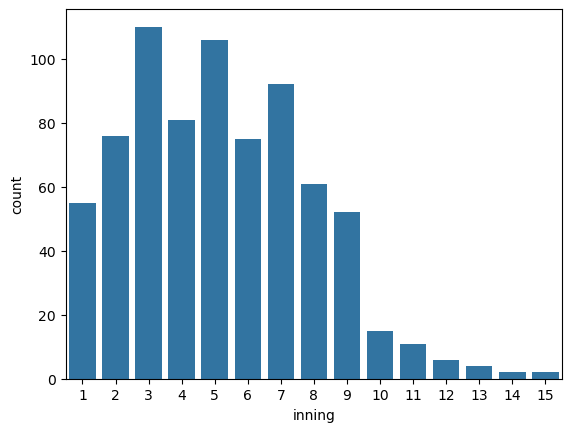

In [84]:
# Visualizing bunts by inning

bunts = df[df['is_bunt'] == True]
sns.countplot(data=bunts, x='inning')

Why are bunts so high in the 3rd inning? Most likely because national league pitchers would bat in the line up then, and they historically were bad hitters and tended to bunt more. 

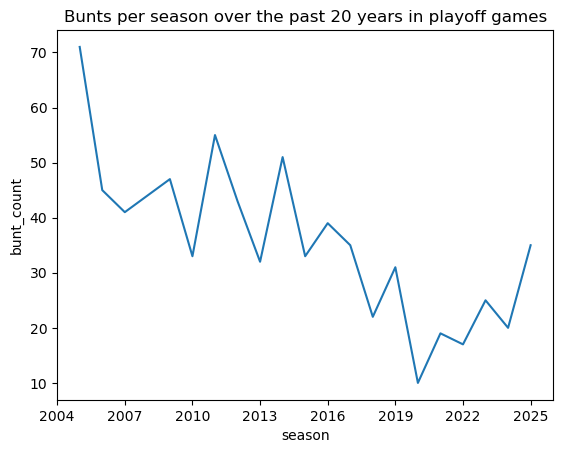

In [85]:
# Visualizing bunts by season

bunts_per_season = df[df['is_bunt'] == True].groupby('season').size().reset_index(name='bunt_count')
ax = sns.lineplot(data=bunts_per_season, x='season', y='bunt_count')
ax.set_title("Bunts per season over the past 20 years in playoff games")
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))


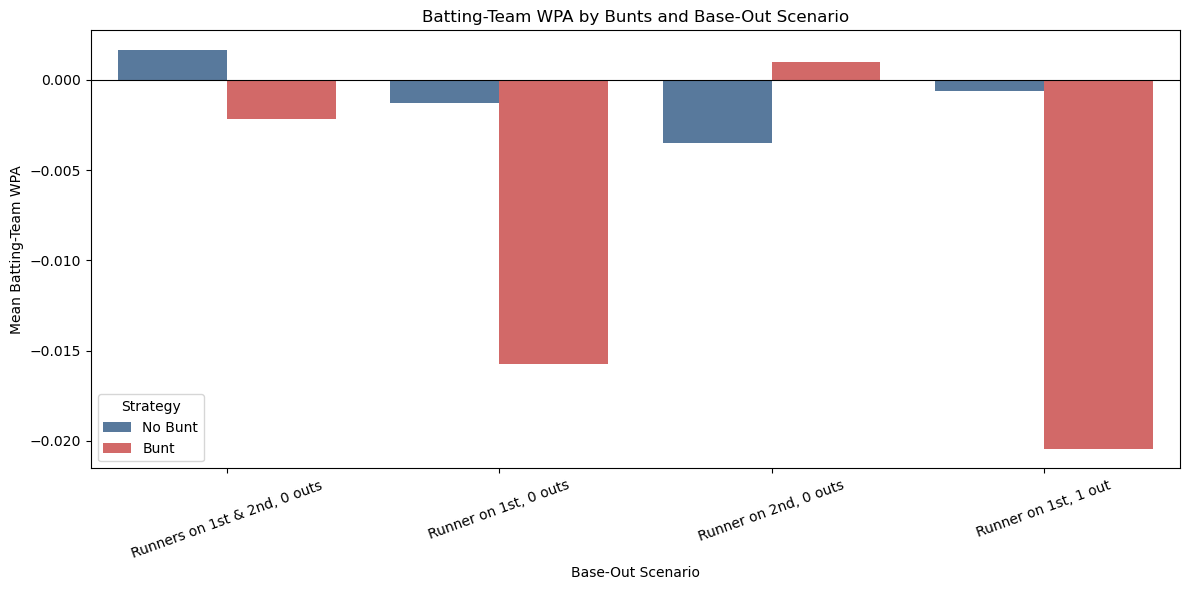

In [88]:
scenario_order = [
    "Runners on 1st & 2nd, 0 outs",
    "Runner on 1st, 0 outs",
    "Runner on 2nd, 0 outs",
    "Runner on 1st, 1 out",
]

scenario_map = {
    ("1_2", 0): "Runners on 1st & 2nd, 0 outs",
    ("1", 0): "Runner on 1st, 0 outs",
    ("2", 0): "Runner on 2nd, 0 outs",
    ("1", 1): "Runner on 1st, 1 out",
}

plot_data = df[
    df.apply(
        lambda row: (str(row["base_state_before"]), row["outs_before"])
        in scenario_map,
        axis=1,
    )
].copy()

plot_data["scenario"] = plot_data.apply(
    lambda row: scenario_map[
        (str(row["base_state_before"]), row["outs_before"])
    ],
    axis=1,
)

plot_data["strategy"] = plot_data["is_bunt"].map({
    False: "No Bunt",
    True: "Bunt",
})

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=plot_data,
    x="scenario",
    y="batting_team_wpa",
    hue="strategy",
    order=scenario_order,
    hue_order=["No Bunt", "Bunt"],
    palette={"No Bunt": "#4C78A8", "Bunt": "#E45756"},
    errorbar=None,
    ax=ax,
)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Batting-Team WPA by Bunts and Base-Out Scenario")
ax.set_xlabel("Base-Out Scenario")
ax.set_ylabel("Mean Batting-Team WPA")
ax.tick_params(axis="x", rotation=20)
ax.legend(title="Strategy")
plt.tight_layout()
plt.show()

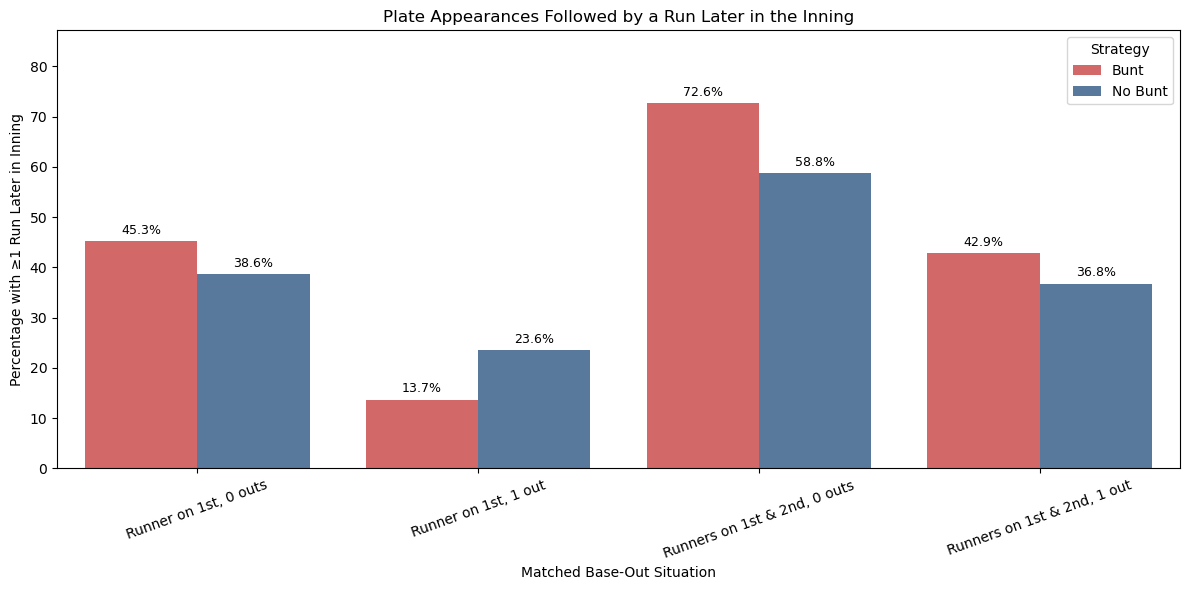

In [89]:
matched_situations = {
    ("1", 0): "Runner on 1st, 0 outs",
    ("1", 1): "Runner on 1st, 1 out",
    ("1_2", 0): "Runners on 1st & 2nd, 0 outs",
    ("1_2", 1): "Runners on 1st & 2nd, 1 out",
}

matched = df[
    df.apply(
        lambda row: (str(row["base_state_before"]), row["outs_before"])
        in matched_situations,
        axis=1,
    )
].copy()

matched["situation"] = matched.apply(
    lambda row: matched_situations[
        (str(row["base_state_before"]), row["outs_before"])
    ],
    axis=1,
)

matched["scored_later"] = matched["runs_rest_of_inning"] > 0
matched["strategy"] = matched["is_bunt"].map({
    True: "Bunt",
    False: "No Bunt",
})

summary = (
    matched
    .groupby(["situation", "strategy"])["scored_later"]
    .agg(["mean", "count"])
    .reset_index()
)

summary["percent"] = summary["mean"] * 100

situation_order = list(matched_situations.values())

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=summary,
    x="situation",
    y="percent",
    hue="strategy",
    order=situation_order,
    hue_order=["Bunt", "No Bunt"],
    palette={"Bunt": "#E45756", "No Bunt": "#4C78A8"},
    ax=ax,
)

for container in ax.containers:
    labels = [
        f"{bar.get_height():.1f}%"
        for bar in container
    ]
    ax.bar_label(container, labels=labels, padding=3, fontsize=9)

ax.set_title(
    "Plate Appearances Followed by a Run Later in the Inning"
)
ax.set_xlabel("Matched Base-Out Situation")
ax.set_ylabel("Percentage with ≥1 Run Later in Inning")
ax.set_ylim(0, max(summary["percent"]) * 1.2)
ax.tick_params(axis="x", rotation=20)
ax.legend(title="Strategy")
plt.tight_layout()
plt.show()

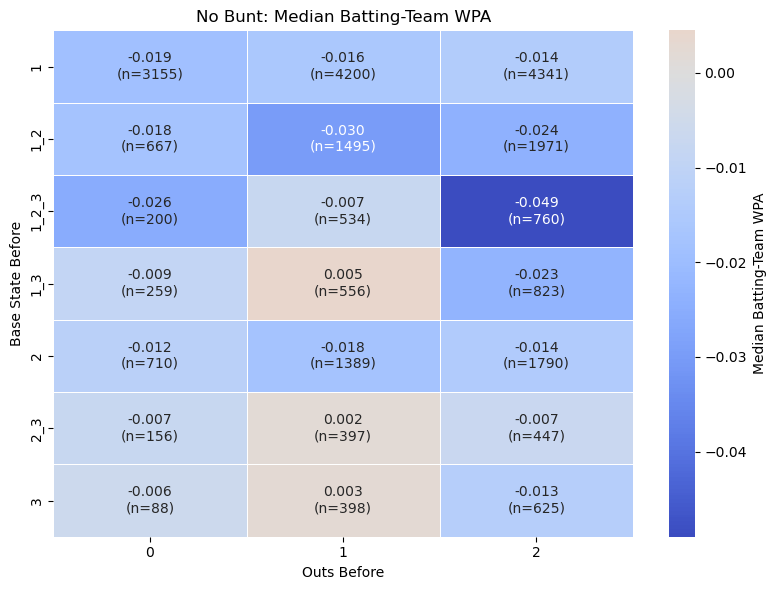

In [90]:
bunt_mask = df["is_bunt"] == False

median_wpa = df[bunt_mask].pivot_table(
    index="base_state_before",
    columns="outs_before",
    values="batting_team_wpa",
    aggfunc="median",
)

sample_size = df[bunt_mask].pivot_table(
    index="base_state_before",
    columns="outs_before",
    values="batting_team_wpa",
    aggfunc="count",
).reindex_like(median_wpa)

annotations = median_wpa.copy().astype(object)

for row in median_wpa.index:
    for col in median_wpa.columns:
        if pd.notna(median_wpa.loc[row, col]):
            annotations.loc[row, col] = (
                f"{median_wpa.loc[row, col]:.3f}\n"
                f"(n={int(sample_size.loc[row, col])})"
            )
        else:
            annotations.loc[row, col] = ""

plt.figure(figsize=(8, 6))

sns.heatmap(
    data=median_wpa,
    annot=annotations,
    fmt="",
    cmap="coolwarm",
    center=0,
    cbar_kws={"label": "Median Batting-Team WPA"},
    linewidths=0.5,
)

plt.title("No Bunt: Median Batting-Team WPA")
plt.xlabel("Outs Before")
plt.ylabel("Base State Before")
plt.tight_layout()
plt.show()

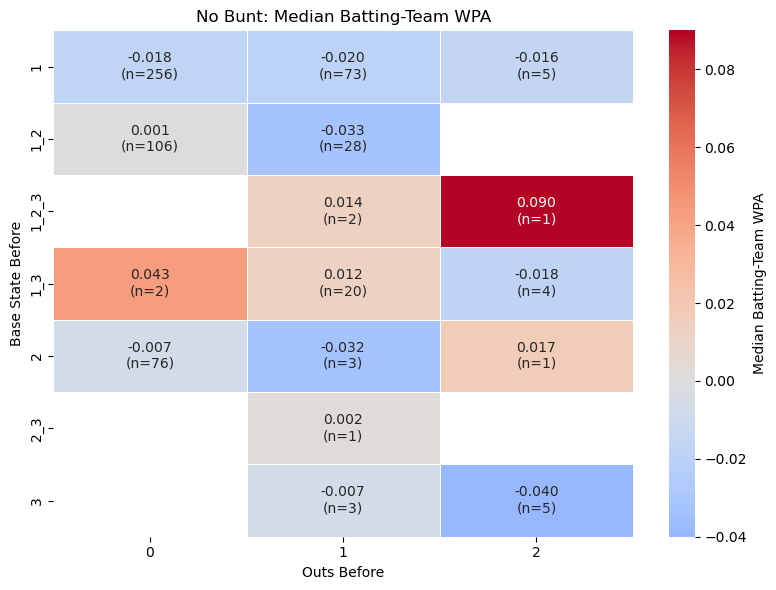

In [91]:
bunt_mask = df["is_bunt"] == True

median_wpa = df[bunt_mask].pivot_table(
    index="base_state_before",
    columns="outs_before",
    values="batting_team_wpa",
    aggfunc="median",
)

sample_size = df[bunt_mask].pivot_table(
    index="base_state_before",
    columns="outs_before",
    values="batting_team_wpa",
    aggfunc="count",
).reindex_like(median_wpa)

annotations = median_wpa.copy().astype(object)

for row in median_wpa.index:
    for col in median_wpa.columns:
        if pd.notna(median_wpa.loc[row, col]):
            annotations.loc[row, col] = (
                f"{median_wpa.loc[row, col]:.3f}\n"
                f"(n={int(sample_size.loc[row, col])})"
            )
        else:
            annotations.loc[row, col] = ""

plt.figure(figsize=(8, 6))

sns.heatmap(
    data=median_wpa,
    annot=annotations,
    fmt="",
    cmap="coolwarm",
    center=0,
    cbar_kws={"label": "Median Batting-Team WPA"},
    linewidths=0.5,
)

plt.title("No Bunt: Median Batting-Team WPA")
plt.xlabel("Outs Before")
plt.ylabel("Base State Before")
plt.tight_layout()
plt.show()